## Problem Statement

Banks issue loans based on a customer’s financial history, but early risk signals are often hidden inside day-to-day account activity like transactions, balances, and recurring payments. When these signals are missed, the bank ends up approving loans for customers who later struggle to repay, leading to higher defaults and financial loss.

In this project, the goal is to build a structured loan risk dataset from raw banking data (accounts, clients, transactions, orders, cards, and district-level demographics) and use it to identify which loan customers are likely to default. The challenge is that the data is stored across multiple tables and contains inconsistencies in date formats, missing values, and relational dependencies that must be cleaned and validated before analysis.

The final outcome is an ML-ready master dataset where each loan is enriched with customer behavior features such as transaction activity, balance patterns, repayment pressure, and region-level indicators—so loan risk can be predicted more accurately and consistently.

In [58]:
import os
import numpy as np
import pandas as pd 
import math 
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
rcParams['figure.figsize']= 20,10
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import mysql.connector as connection

In [88]:
sql = ("SELECT * FROM loan_master;")
mydb = connection.connect(host = "localhost",database = 'cap_prj',user = "root",passwd = "Dnyanesh@123",use_pure = True)
df = pd.read_sql(sql,mydb)
display(df)

C:\Users\Asus\AppData\Local\Temp\ipykernel_24500\3256995492.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql,mydb)


,Loan_ID,Account_ID,Loan_Date,Loan_Amount,Duration,Payments,Status,Frequency,Account_Date,Client_ID,...,Gold_Card_Count,District_Name,Region,Avg_Salary,Unemployment_Rate_1,Unemployment_Rate_2,Avg_Unemployment_Rate,Entrepreneurs_Per_1000,Crimes_1,Crimes_2
0,5314,1787,1993-07-05,96396,12,8033,B,POPLATEK TYDNE,1993-03-22,2166,...,0.0,Sokolov,west Bohemia,9650,3.38,3.67,3.525,100,2985.0,2804
1,5316,1801,1993-07-11,165960,36,4610,A,POPLATEK MESICNE,1993-02-13,2181,...,0.0,Nachod,east Bohemia,8369,1.79,2.31,2.050,117,2854.0,2618
2,5325,1843,1993-08-03,105804,36,2939,A,POPLATEK MESICNE,1993-01-30,2235,...,0.0,Pribram,central Bohemia,8754,3.83,4.31,4.070,137,3804.0,3868
3,5523,2705,1993-12-08,93888,36,2608,A,POPLATEK PO OBRATU,1993-07-05,3264,...,0.0,Vyskov,south Moravia,8288,3.79,4.52,4.155,110,1562.0,1460
4,4959,2,1994-01-05,80952,24,3373,A,POPLATEK MESICNE,1993-02-26,2,...,0.0,Hl.m. Praha,Prague,12541,0.29,0.43,0.360,167,85677.0,99107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677,6469,7180,1998-11-17,99744,24,4156,C,POPLATEK TYDNE,1997-06-12,8666,...,0.0,Melnik,central Bohemia,9920,2.26,2.87,2.565,130,4289.0,4846
678,7292,11317,1998-11-22,317460,60,5291,C,POPLATEK MESICNE,1997-07-11,13912,...,0.0,Svitavy,east Bohemia,8187,4.83,5.45,5.140,94,2123.0,2134
679,6856,9156,1998-12-01,163332,36,4537,C,POPLATEK MESICNE,1997-09-14,11271,...,0.0,Pisek,south Bohemia,8968,2.83,3.35,3.090,131,1740.0,1910
680,6402,6922,1998-12-06,139488,24,5812,C,POPLATEK TYDNE,1997-05-12,8356,...,0.0,Beroun,central Bohemia,8980,1.95,2.21,2.080,111,2824.0,2813


In [89]:
print("Shape Of Data :", df.shape)

Shape Of Data : (682, 37)


In [90]:
df.dtypes

Loan_ID                     int64
Account_ID                  int64
Loan_Date                  object
Loan_Amount                 int64
Duration                    int64
Payments                    int64
Status                     object
Frequency                  object
Account_Date               object
Client_ID                   int64
Owner_Count               float64
User_Count                float64
Is_Joint_Account            int64
Txn_Count                   int64
Active_Days                 int64
Avg_Trans_Amount          float64
Total_Trans_Amount        float64
Avg_Balance               float64
Balance_Volatility        float64
Total_Credit              float64
Total_Debit               float64
Net_Cashflow              float64
Order_Count                 int64
Total_Order_Amount        float64
Avg_Order_Amount          float64
Card_Count                  int64
Has_Card                    int64
Gold_Card_Count           float64
District_Name              object
Region        

In [91]:
df.columns

Index(['Loan_ID', 'Account_ID', 'Loan_Date', 'Loan_Amount', 'Duration',
       'Payments', 'Status', 'Frequency', 'Account_Date', 'Client_ID',
       'Owner_Count', 'User_Count', 'Is_Joint_Account', 'Txn_Count',
       'Active_Days', 'Avg_Trans_Amount', 'Total_Trans_Amount', 'Avg_Balance',
       'Balance_Volatility', 'Total_Credit', 'Total_Debit', 'Net_Cashflow',
       'Order_Count', 'Total_Order_Amount', 'Avg_Order_Amount', 'Card_Count',
       'Has_Card', 'Gold_Card_Count', 'District_Name', 'Region', 'Avg_Salary',
       'Unemployment_Rate_1', 'Unemployment_Rate_2', 'Avg_Unemployment_Rate',
       'Entrepreneurs_Per_1000', 'Crimes_1', 'Crimes_2'],
      dtype='object')

In [92]:
print("Null Count")
print(df.isnull().sum())

Null Count
Loan_ID                   0
Account_ID                0
Loan_Date                 0
Loan_Amount               0
Duration                  0
Payments                  0
Status                    0
Frequency                 0
Account_Date              0
Client_ID                 0
Owner_Count               0
User_Count                0
Is_Joint_Account          0
Txn_Count                 0
Active_Days               0
Avg_Trans_Amount          0
Total_Trans_Amount        0
Avg_Balance               0
Balance_Volatility        0
Total_Credit              0
Total_Debit               0
Net_Cashflow              0
Order_Count               0
Total_Order_Amount        0
Avg_Order_Amount          0
Card_Count                0
Has_Card                  0
Gold_Card_Count           0
District_Name             0
Region                    0
Avg_Salary                0
Unemployment_Rate_1       8
Unemployment_Rate_2       0
Avg_Unemployment_Rate     8
Entrepreneurs_Per_1000    0
Crimes_1 

In [93]:
display(df.Status.unique())

array(['B', 'A', 'C', 'D'], dtype=object)

In [94]:
df['Status'].value_counts()

Status
C    403
A    203
D     45
B     31
Name: count, dtype: int64

In [95]:
# map values to a column
df['Status'] = df.Status.map({'A':0, 'B':1, 'C':2, 'D':3})
display(df['Status'])

0      1
1      0
2      0
3      0
4      0
      ..
677    2
678    2
679    2
680    2
681    2
Name: Status, Length: 682, dtype: int64

In [96]:
display(df.Status.value_counts())

Status
2    403
0    203
3     45
1     31
Name: count, dtype: int64

In [100]:
X = df[
    ['Loan_Amount','Duration','Payments',
     'Avg_Salary','Avg_Unemployment_Rate','Entrepreneurs_Per_1000',
     'Txn_Count','Avg_Balance','Balance_Volatility','Net_Cashflow',
     'Is_Joint_Account','Has_Card','Gold_Card_Count',
     'Total_Order_Amount','Avg_Trans_Amount','Unemployment_Rate_1',
     'Unemployment_Rate_2','Crimes_1']
]

In [101]:
y = df['Status'].values
display(y)

array([1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 2, 0, 0, 2, 3, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 2, 2, 0, 3, 0, 2, 0, 2, 3, 0, 2, 0, 1, 0, 1, 2, 0,
       2, 2, 0, 0, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2, 3, 2, 3, 2, 2, 1, 0, 2,
       2, 2, 2, 0, 2, 2, 0, 2, 2, 0, 3, 3, 2, 2, 3, 0, 2, 2, 2, 0, 0, 2,
       2, 0, 2, 3, 0, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 3, 3, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 3, 2, 2, 2, 0, 2, 0, 0, 2, 2, 0, 1, 0, 0, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 0, 3, 2, 0, 2, 3, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 1, 0, 0, 2, 2, 0, 0, 0, 1, 1, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 2, 0, 3, 0, 2, 2,
       2, 0, 2, 0, 0, 0, 0, 1, 0, 2, 2, 2, 2, 3, 0, 1, 3, 2, 0, 3, 2, 1,
       2, 2, 2, 0, 2, 0, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 3, 0, 2, 0, 3, 0, 2, 3, 2, 2,

In [107]:
df['Unemployment_Rate_1'] = df['Unemployment_Rate_1'].fillna(df['Unemployment_Rate_1'].mean())
df['Avg_Unemployment_Rate'] = df['Avg_Unemployment_Rate'].fillna(df['Avg_Unemployment_Rate'].mean())
df['Crimes_1'] = df['Crimes_1'].fillna(df['Crimes_1'].mean())

In [111]:
print(df.isnull().sum())

Loan_ID                   0
Account_ID                0
Loan_Date                 0
Loan_Amount               0
Duration                  0
Payments                  0
Status                    0
Frequency                 0
Account_Date              0
Client_ID                 0
Owner_Count               0
User_Count                0
Is_Joint_Account          0
Txn_Count                 0
Active_Days               0
Avg_Trans_Amount          0
Total_Trans_Amount        0
Avg_Balance               0
Balance_Volatility        0
Total_Credit              0
Total_Debit               0
Net_Cashflow              0
Order_Count               0
Total_Order_Amount        0
Avg_Order_Amount          0
Card_Count                0
Has_Card                  0
Gold_Card_Count           0
District_Name             0
Region                    0
Avg_Salary                0
Unemployment_Rate_1       0
Unemployment_Rate_2       0
Avg_Unemployment_Rate     0
Entrepreneurs_Per_1000    0
Crimes_1            

In [108]:
from sklearn.preprocessing import MinMaxScaler
sc_x = MinMaxScaler()
X = sc_x.fit_transform(X)
print(X)

[[0.15604261 0.         0.80460129 ... 0.43829787 0.36120401 0.02553648]
 [0.27478492 0.5        0.4482615  ... 0.21276596 0.20958751 0.02399274]
 [0.1721016  0.5        0.27430772 ... 0.50212766 0.43255295 0.03518778]
 ...
 [0.27029906 0.5        0.44066209 ... 0.36028369 0.32552954 0.01086508]
 [0.22959853 0.25       0.57339163 ... 0.23546099 0.19843924 0.02363921]
 [0.40270381 1.         0.38632105 ... 0.44822695 0.45150502 0.01250309]]


In [109]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state= 43)
display(X_train.shape)
display(X_test.shape)
display(y_train.shape)
display(y_test.shape)

(477, 18)

(205, 18)

(477,)

(205,)

In [114]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [128]:
accuracy = []
for i in range (1,15):
    knn = KNeighborsClassifier(n_neighbors= i)
    knn = knn.fit(X_train, y_train)
    y_pred = knn.predict(X_train)
    KNC_acc = accuracy_score(y_train,y_pred)
    accuracy.append(KNC_acc)

In [129]:
display(accuracy)

[1.0,
 0.8259958071278826,
 0.7861635220125787,
 0.7631027253668763,
 0.7589098532494759,
 0.7463312368972747,
 0.7295597484276729,
 0.7421383647798742,
 0.710691823899371,
 0.7232704402515723,
 0.7232704402515723,
 0.7232704402515723,
 0.7211740041928721,
 0.7274633123689728]

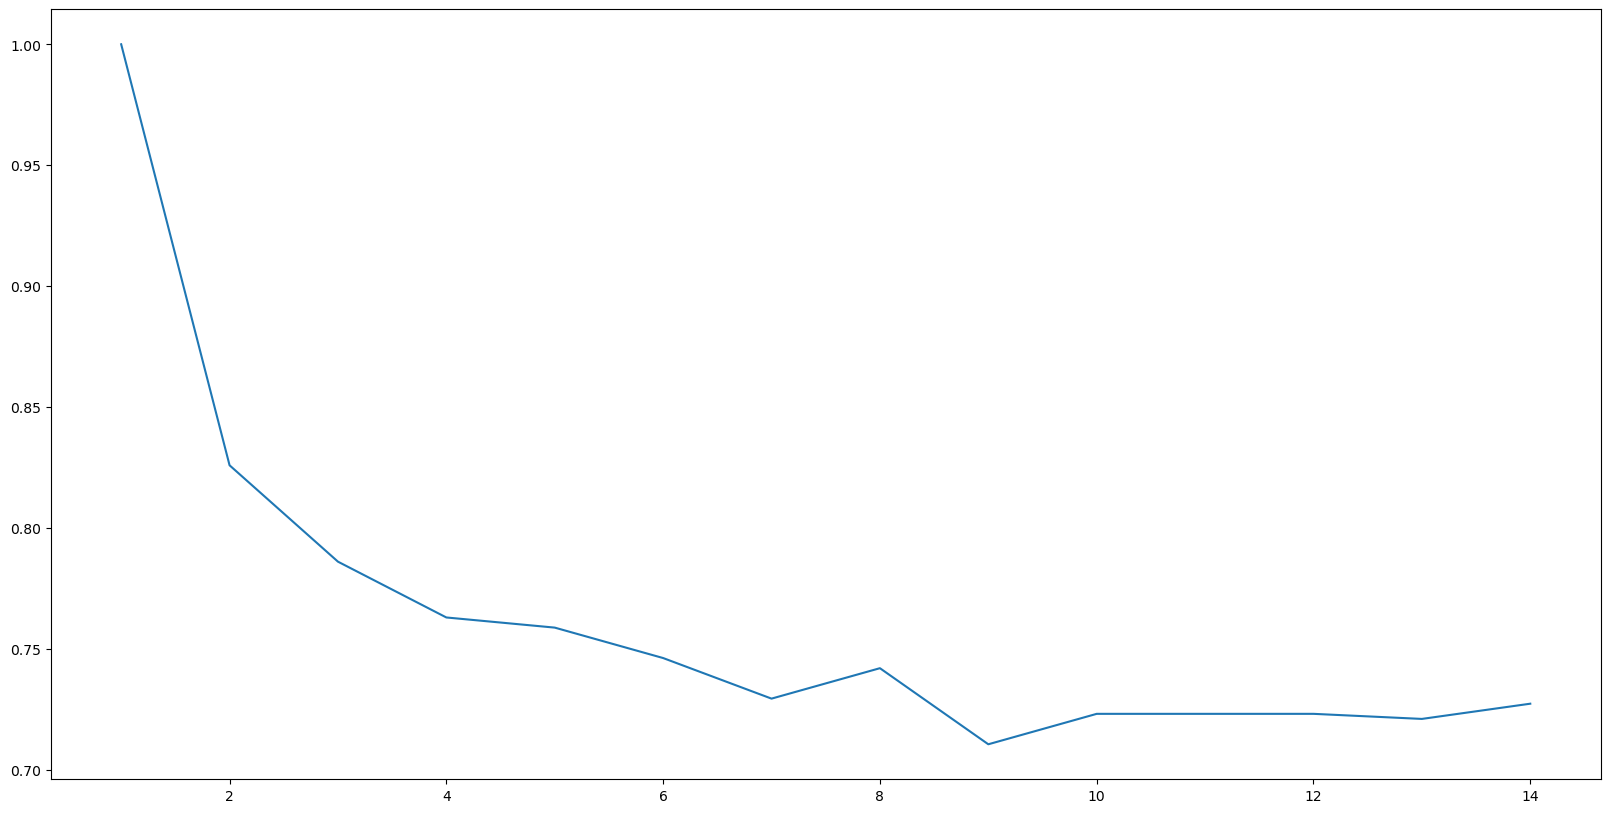

In [117]:
plt.plot(range(1,15),accuracy)
plt.show()

In [118]:
knn = KNeighborsClassifier(n_neighbors= 3)
knn = knn.fit(X_train, y_train)


In [131]:
y_pred = knn.predict(X_test)
K_ACC = accuracy_score(y_pred, y_test)
print(K_ACC)

0.6878048780487804


In [120]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.61      0.59        61
           1       0.33      0.09      0.14        11
           2       0.74      0.80      0.77       122
           3       0.33      0.18      0.24        11

    accuracy                           0.67       205
   macro avg       0.50      0.42      0.44       205
weighted avg       0.65      0.67      0.66       205



In [121]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[37  2 22  0]
 [ 6  1  4  0]
 [20  0 98  4]
 [ 1  0  8  2]]


In [132]:
from sklearn.tree import DecisionTreeClassifier
TREE = DecisionTreeClassifier(criterion= 'entropy')
TREE.fit(X_train, y_train)
TREE_pred =TREE.predict(X_test)
print(TREE_pred)
print(pd.DataFrame(TREE_pred).groupby(0).agg({0:np.size}))
print('\n Accuracy Score')
D_ACC = accuracy_score(y_test,TREE_pred)
print(D_ACC)
print('\n Classification Report')
print(classification_report(y_test, TREE_pred))
print('Confusion Matrix')
print(confusion_matrix(y_test, TREE_pred))

[2 0 3 2 2 2 2 2 2 2 0 2 0 2 2 0 0 2 1 2 0 2 2 2 0 1 2 2 2 2 3 0 2 1 2 0 1
 0 2 0 2 2 0 2 3 2 2 3 0 2 2 1 2 2 2 0 2 2 0 2 2 2 2 2 1 2 2 2 2 2 2 2 2 0
 2 0 2 2 0 2 2 2 3 2 3 0 2 3 2 0 2 2 0 0 2 2 2 2 2 2 0 2 0 1 3 2 3 2 0 0 2
 2 2 2 0 2 2 2 2 2 2 1 3 2 2 0 2 2 3 2 2 0 2 2 1 2 2 1 2 2 0 2 2 2 2 0 2 1
 0 0 2 0 2 2 2 2 0 2 1 2 2 0 0 2 2 0 2 2 0 2 2 2 2 0 2 2 2 0 2 0 2 2 0 2 3
 2 2 1 2 2 0 2 2 2 2 2 3 2 2 2 2 2 0 1 2]
     0
0     
0   45
1   14
2  133
3   13

 Accuracy Score
0.6390243902439025

 Classification Report
              precision    recall  f1-score   support

           0       0.67      0.49      0.57        61
           1       0.14      0.18      0.16        11
           2       0.73      0.80      0.76       122
           3       0.15      0.18      0.17        11

    accuracy                           0.64       205
   macro avg       0.42      0.41      0.41       205
weighted avg       0.65      0.64      0.64       205

Confusion Matrix
[[30  6 24  1]
 [ 4  2  5  0]

In [136]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
L_pred = model.predict(X_test)
print (L_pred)
print (pd.DataFrame(y_pred).groupby(0).agg({0:np.size}))
print('\n Accuracy Score')
L_ACC = accuracy_score (y_test,L_pred)
print(L_ACC)
print('\nClassification Report')
print(classification_report (y_test,L_pred))
print('Confusion Matrix')
print (confusion_matrix (y_test,L_pred))

[2 0 2 2 0 2 2 0 0 2 0 2 0 2 2 0 2 0 2 2 0 2 2 2 0 0 2 2 2 0 0 2 2 2 2 2 2
 0 0 2 0 2 0 2 2 2 2 2 0 2 2 0 2 2 2 0 2 2 0 2 2 2 0 2 2 2 0 2 2 2 2 2 2 2
 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 0 0 2 2 2 2 2 2 0 2 0 2 2 2 2 2 0 2 2
 0 2 2 0 2 0 2 2 0 2 0 2 2 2 0 2 2 2 2 0 0 2 2 0 2 2 0 2 2 2 2 0 2 2 0 2 2
 2 0 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 0 2 0 2 2 2 2 2 2 2 2 2 2 0 2 0 2 2 2
 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2]
     0
0     
0   53
2  152

 Accuracy Score
0.7219512195121951

Classification Report
              precision    recall  f1-score   support

           0       0.70      0.61      0.65        61
           1       0.00      0.00      0.00        11
           2       0.73      0.91      0.81       122
           3       0.00      0.00      0.00        11

    accuracy                           0.72       205
   macro avg       0.36      0.38      0.36       205
weighted avg       0.64      0.72      0.68       205

Confusion Matrix
[[ 37   0  24   0]
 [  5   0   6   0]
 [ 11 

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [137]:
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier(n_estimators=50, criterion='entropy')
RF.fit(X_train,y_train)
RF_pred = RF.predict(X_test)
print (RF_pred)
print (pd.DataFrame(RF_pred).groupby(0).agg({0:np.size}))
print('\n Accuracy Score')
R_ACC = accuracy_score (y_test,RF_pred)
print(R_ACC)
print('\nClassification Report')
print(classification_report (y_test,RF_pred))
print('Confusion Matrix')
print (confusion_matrix (y_test,RF_pred))

[2 0 3 2 0 2 2 2 2 0 0 2 0 2 2 0 0 0 0 2 0 2 2 2 0 0 2 2 2 0 0 0 2 2 2 2 0
 0 2 2 2 2 0 2 2 2 2 2 0 2 2 0 2 2 2 0 2 2 0 2 2 0 0 2 2 2 0 2 2 2 2 2 2 0
 2 0 2 2 0 2 2 2 3 2 2 2 2 2 2 0 2 2 0 2 2 2 2 2 2 2 0 2 0 2 2 2 2 2 0 2 2
 0 2 2 0 2 2 2 2 0 2 1 2 2 2 0 2 0 2 2 0 0 2 2 0 2 2 0 2 2 0 2 2 2 2 0 0 0
 2 0 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 0 2 0 2 2 2 2 0
 0 2 0 2 2 0 2 2 2 2 2 2 2 2 2 2 2 0 2 2]
     0
0     
0   57
1    1
2  145
3    2

 Accuracy Score
0.7024390243902439

Classification Report
              precision    recall  f1-score   support

           0       0.63      0.59      0.61        61
           1       1.00      0.09      0.17        11
           2       0.73      0.87      0.79       122
           3       0.50      0.09      0.15        11

    accuracy                           0.70       205
   macro avg       0.72      0.41      0.43       205
weighted avg       0.70      0.70      0.67       205

Confusion Matrix
[[ 36   0  25   0]
 [  4   1  

In [138]:
print('KNeighborsClassifier Accuracy :',K_ACC )
print('DecisionTreeClassifier Accuracy :',D_ACC )
print('RandomForestClassifier Accuracy :',R_ACC )
print('LogisticRegression Accuracy :',L_ACC )


KNeighborsClassifier Accuracy : 0.6878048780487804
DecisionTreeClassifier Accuracy : 0.6390243902439025
RandomForestClassifier Accuracy : 0.7024390243902439
LogisticRegression Accuracy : 0.7219512195121951
